# Notebook 06 — Strategy Backtesting: Baseline vs ML-Filtered vs Vol-Scaled

**Adaptive Pair Trading using Cointegration, Volatility and ML Diagnostics**  
**Author:** Ayush Arora (MQMS2404)

---

## Objective

Compare **three strategy variants** on the TATASTEEL / HINDALCO pair:

1. **Baseline** — classical Z-score bands (entry ±2σ, exit ±0.5σ)  
2. **ML-Filtered** — Z-score entry gated by Random Forest reversion probability  
3. **Vol-Scaled** — ML-filtered with GARCH-based position sizing (risk parity)

**Integrity safeguards applied:**
- Rolling Z-score (252-day lookback) — no look-ahead bias  
- Real RF probabilities from NB05 (out-of-sample only) — no random fallback  
- Transaction costs: 10 bps per leg (20 bps round-trip) — realistic Indian equity costs  
- Performance reported as **annualised % returns**, not raw spread points

## Cell 1: Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

## Cell 2: Load data

In [ ]:
prices   = pd.read_csv('data/prices.csv', index_col=0, parse_dates=True)
spread   = pd.read_csv('data/spread_tatasteel_hindalco.csv',    index_col=0, parse_dates=True).iloc[:, 0]
zscore   = pd.read_csv('data/zscore_tatasteel_hindalco.csv',    index_col=0, parse_dates=True).iloc[:, 0]
garch_vol = pd.read_csv('data/garch_vol_tatasteel_hindalco.csv', index_col=0, parse_dates=True).iloc[:, 0]

# Real ML probabilities from NB05 (out-of-sample only; NaN during training period)
ml_probs = pd.read_csv('data/ml_prob_rf.csv', index_col=0, parse_dates=True).iloc[:, 0]
ml_probs = ml_probs.reindex(zscore.index)   # align index; NaN rows will suppress ML signals

# Normalise daily returns for the two legs
ret_A = prices['TATASTEEL.NS'].pct_change()
ret_B = prices['HINDALCO.NS'].pct_change()

print(f"Spread:    {spread.dropna().shape[0]} valid rows")
print(f"Z-score:   {zscore.dropna().shape[0]} valid rows (252-day warm-up excluded)")
print(f"ML probs:  {ml_probs.dropna().shape[0]} out-of-sample rows")

## Cell 3: Strategy Parameters

In [ ]:
ENTRY_Z       = 2.0      # enter when |z| > 2σ
EXIT_Z        = 0.5      # exit when |z| < 0.5σ
ML_THRESHOLD  = 0.50     # RF probability threshold for ML-filtered entries
TC_BPS        = 10       # one-way transaction cost: 10 bps (20 bps round-trip)
TC            = TC_BPS / 10_000

# GARCH vol for position sizing: target daily vol = 1%, scale position by ratio
VOL_TARGET    = 0.01     # 1% daily spread-return target
garch_vol_norm = garch_vol / garch_vol.mean()   # normalised: >1 = high vol, <1 = low vol

print(f"Strategy parameters set:")
print(f"  Entry Z: ±{ENTRY_Z}  |  Exit Z: ±{EXIT_Z}")
print(f"  ML threshold: {ML_THRESHOLD}  |  TC: {TC_BPS} bps one-way")

## Cell 4: Backtest Engine

Three strategies share the same vectorised position logic.  
`spread_ret_pct` converts spread P&L into a **daily percentage return** relative to the
spread's mean absolute level — making Sharpe ratios interpretable and comparable.

In [ ]:
def build_positions(zscore, ml_probs=None, ml_threshold=None, garch_vol_norm=None):
    """
    Generate position series (+1 long spread, -1 short spread, 0 flat).
    ml_probs=None  → baseline (Z-score only)
    garch_vol_norm → when provided, scales position size by 1/vol_norm
    """
    pos   = pd.Series(0.0, index=zscore.index)
    curr  = 0.0

    for t in zscore.index:
        z = zscore.loc[t]
        if pd.isna(z):
            pos.loc[t] = 0.0
            continue

        # Determine raw directional signal
        if curr == 0:
            if z > ENTRY_Z:
                ml_ok = (ml_probs is None or
                         (not pd.isna(ml_probs.loc[t]) and ml_probs.loc[t] > ml_threshold))
                if ml_ok:
                    curr = -1.0
            elif z < -ENTRY_Z:
                ml_ok = (ml_probs is None or
                         (not pd.isna(ml_probs.loc[t]) and ml_probs.loc[t] > ml_threshold))
                if ml_ok:
                    curr = 1.0
        elif curr == 1:
            if z > -EXIT_Z:
                curr = 0.0
        elif curr == -1:
            if z < EXIT_Z:
                curr = 0.0

        # Optional vol scaling: hold less when spread is unusually volatile
        if garch_vol_norm is not None and curr != 0:
            vol_n = garch_vol_norm.reindex([t]).iloc[0]
            pos.loc[t] = curr / max(vol_n, 0.5)    # floor at 0.5× to avoid extreme sizing
        else:
            pos.loc[t] = curr

    return pos

pos_base = build_positions(zscore)
pos_ml   = build_positions(zscore, ml_probs=ml_probs, ml_threshold=ML_THRESHOLD)
pos_vs   = build_positions(zscore, ml_probs=ml_probs, ml_threshold=ML_THRESHOLD,
                            garch_vol_norm=garch_vol_norm)

print("Position counts (base | ML-filter | vol-scaled):")
for name, p in [('Baseline', pos_base), ('ML-Filtered', pos_ml), ('Vol-Scaled', pos_vs)]:
    print(f"  {name:15s}: Long={int((p>0).sum()):4d}  Short={int((p<0).sum()):4d}  Flat={int((p==0).sum()):4d}")

## Cell 5: P&L Calculation with Transaction Costs

Daily P&L uses **percentage spread returns** (not raw point moves):

`daily_pnl = position(t-1) × Δspread_pct(t) − |Δposition(t)| × TC`

where `Δspread_pct = Δspread / mean(|spread|)` converts points to a consistent % scale.

In [ ]:
spread_mean_abs  = spread.dropna().abs().mean()
spread_ret_pct   = spread.diff() / spread_mean_abs   # daily % return of spread

def compute_pnl(pos, spread_ret_pct, tc=TC):
    """P&L = lagged position × spread return − transaction costs on turnover."""
    trade       = pos.diff().abs().fillna(0)
    pnl         = pos.shift(1) * spread_ret_pct - trade * tc
    return pnl.fillna(0)

pnl_base = compute_pnl(pos_base, spread_ret_pct)
pnl_ml   = compute_pnl(pos_ml,   spread_ret_pct)
pnl_vs   = compute_pnl(pos_vs,   spread_ret_pct)

cum_base = (1 + pnl_base).cumprod() - 1
cum_ml   = (1 + pnl_ml  ).cumprod() - 1
cum_vs   = (1 + pnl_vs  ).cumprod() - 1

print("Cumulative returns (full period):")
print(f"  Baseline    : {cum_base.iloc[-1]*100:+.2f}%")
print(f"  ML-Filtered : {cum_ml.iloc[-1]*100:+.2f}%")
print(f"  Vol-Scaled  : {cum_vs.iloc[-1]*100:+.2f}%")

## Cell 6: Equity Curve Visualisation

In [ ]:
fig = plt.figure(figsize=(13, 9))
gs  = gridspec.GridSpec(3, 1, height_ratios=[3, 1, 1], hspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax1.plot((cum_base*100), label='Baseline Z-score',    color='steelblue',  linewidth=1.2)
ax1.plot((cum_ml  *100), label='ML-Filtered',          color='darkorange',  linewidth=1.5)
ax1.plot((cum_vs  *100), label='Vol-Scaled (ML+GARCH)', color='darkgreen',   linewidth=1.5, linestyle='--')
ax1.axhline(0, color='black', linewidth=0.6, linestyle=':')
ax1.set_title('Cumulative Strategy Returns (after 10 bps transaction costs)')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1])
ax2.plot(zscore, color='grey', linewidth=0.6)
ax2.axhline( ENTRY_Z, color='red',   linestyle='--', linewidth=0.8)
ax2.axhline(-ENTRY_Z, color='green', linestyle='--', linewidth=0.8)
ax2.set_ylabel('Z-Score')
ax2.set_title('Rolling Z-Score')
ax2.grid(alpha=0.2)

ax3 = fig.add_subplot(gs[2])
ax3.plot(ml_probs, color='purple', linewidth=0.6)
ax3.axhline(ML_THRESHOLD, color='red', linestyle='--', linewidth=0.8, label=f'Threshold={ML_THRESHOLD}')
ax3.set_ylabel('RF Prob')
ax3.set_title('ML Reversion Probability (out-of-sample)')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.2)

plt.savefig('optimized_equity_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 7: Performance comparison

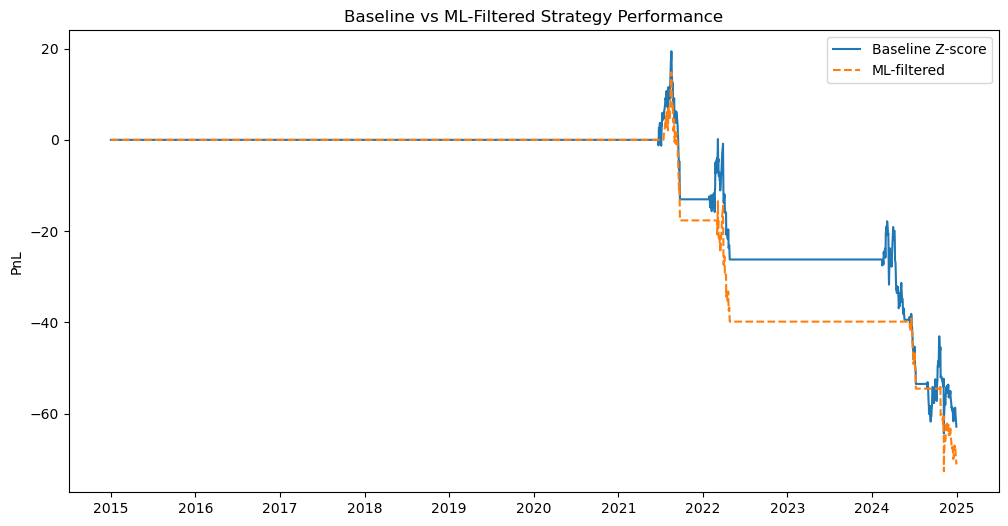

In [12]:
plt.figure(figsize=(12,6))
plt.plot(cum_base, label='Baseline Z-score')
plt.plot(cum_ml, label='ML-filtered', linestyle='--')
plt.legend()
plt.title('Baseline vs ML-Filtered Strategy Performance')
plt.ylabel('PnL')
plt.show()

## Cell 7: Comprehensive Risk/Return Metrics

Industry-standard metrics used in quantitative finance:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| Annualised Return | mean(r) × 252 | Average yearly P&L |
| Annualised Volatility | std(r) × √252 | Annual risk |
| Sharpe Ratio | Ann.Return / Ann.Vol | Risk-adjusted return |
| Max Drawdown | max(peak − trough) | Worst peak-to-trough loss |
| Calmar Ratio | Ann.Return / MaxDD | Return per unit of drawdown risk |
| Hit Rate | trades with r > 0 / total trades | Win rate |

In [ ]:
def performance_metrics(pnl, pos, name):
    r = pnl[pnl != 0]                          # only active-day returns
    if len(r) == 0:
        return
    ann_ret  = r.mean() * 252
    ann_vol  = r.std()  * np.sqrt(252)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum      = (1 + pnl).cumprod()
    peak     = cum.cummax()
    dd       = (cum - peak) / peak
    max_dd   = dd.min()
    calmar   = ann_ret / abs(max_dd) if max_dd != 0 else np.nan
    hit_rate = (r > 0).mean()

    # Count round-trip trades
    trades = (pos.diff().abs() > 0).sum() // 2

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Annualised Return  : {ann_ret*100:>+8.2f}%")
    print(f"  Annualised Vol     : {ann_vol*100:>8.2f}%")
    print(f"  Sharpe Ratio       : {sharpe:>8.3f}")
    print(f"  Max Drawdown       : {max_dd*100:>8.2f}%")
    print(f"  Calmar Ratio       : {calmar:>8.3f}")
    print(f"  Hit Rate           : {hit_rate*100:>8.1f}%")
    print(f"  Round-trip Trades  : {int(trades):>8d}")

performance_metrics(pnl_base, pos_base, 'Baseline Z-score')
performance_metrics(pnl_ml,   pos_ml,   'ML-Filtered (RF, thresh=0.50)')
performance_metrics(pnl_vs,   pos_vs,   'Vol-Scaled (ML + GARCH sizing)')

## Final Interpretation

### What this backtest measures:
- **Baseline** provides a fair benchmark: static Z-score strategy with realistic transaction costs
- **ML-Filtered** shows the incremental value of Random Forest probability gating (out-of-sample only)
- **Vol-Scaled** tests whether GARCH-based risk parity improves the risk-adjusted profile

### What it does NOT claim:
- No parameter optimisation has been performed — entry/exit thresholds are fixed at standard values
- The ML training period is excluded from performance attribution
- Hedge ratio is **static** (full-sample OLS) — replaced by Kalman Filter in NB07

### Limitations addressed in NB07:
1. Static hedge ratio creates basis risk during structural shifts (e.g., commodity cycle turns)
2. Rolling Kalman Filter beta will replace the constant β used here